# Instalação

In [ ]:
# Install required packages.
import os
import torch
os.environ['TORCH'] = torch.__version__
print(torch.__version__)

!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git

2.0.1+cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 39.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 32.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
!cat /proc/cpuinfo
!df -h
!cat /proc/meminfo
!nvidia-smi
!nvidia-smi --query-gpu=memory.total

processor	: 0
vendor_id	: AuthenticAMD
cpu family	: 23
model		: 49
model name	: AMD EPYC 7B12
stepping	: 0
microcode	: 0xffffffff
cpu MHz		: 2249.998
cache size	: 512 KB
physical id	: 0
siblings	: 2
core id		: 0
cpu cores	: 1
apicid		: 0
initial apicid	: 0
fpu		: yes
fpu_exception	: yes
cpuid level	: 13
wp		: yes
flags		: fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ht syscall nx mmxext fxsr_opt pdpe1gb rdtscp lm constant_tsc rep_good nopl nonstop_tsc cpuid extd_apicid tsc_known_freq pni pclmulqdq ssse3 fma cx16 sse4_1 sse4_2 movbe popcnt aes xsave avx f16c rdrand hypervisor lahf_lm cmp_legacy cr8_legacy abm sse4a misalignsse 3dnowprefetch osvw topoext ssbd ibrs ibpb stibp vmmcall fsgsbase tsc_adjust bmi1 avx2 smep bmi2 rdseed adx smap clflushopt clwb sha_ni xsaveopt xsavec xgetbv1 clzero xsaveerptr arat npt nrip_save umip rdpid
bugs		: sysret_ss_attrs null_seg spectre_v1 spectre_v2 spec_store_bypass retbleed smt_rsb
bogomips	: 4499.

In [ ]:
!pip install nvidia-ml-py3
!pip install ipython-autotime
!apt install sysstat
%load_ext autotime

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Preparing metadata (setup.py) ... done
  Created wheel for nvidia-ml-py3: filename=nvidia_ml_py3-7.352.0-py3-none-any.whl size=19171 sha256=78416961cddc156125ea769daa2dde0528cf4d43502a5ad0265386b320d09aba
  Stored in directory: /root/.cache/pip/wheels/5c/d8/c0/46899f8be7a75a2ffd197a23c8797700ea858b9b34819fbf9e
Successfully built nvidia-ml-py3
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.1 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree       
Reading state information... Done
The following additional packages will be installed:
  cron
Suggested packages:
  anacron logrotate checksecurity default-mta | mail-transport-agent isag
The following NEW packages will be installed:
  cron sysstat
0 upgraded, 2 newly installed, 0 to remove and 34 not upgraded.
N

In [ ]:
# !sar -q 1 100 >> /tmp/report_cpu_queue.txt
# !sar -uq 1 1 | awk 'BEGIN {printf "%-10s\n","%idle"} NR>3 {printf "%-10s\n", $6}'
# !sar -uq 1 1
# !paste <(sar -u 1 5) <(sar -q 1 5) >> /tmp/sar.out

Linux 5.10.147+ (14bf035bf07a) 	03/16/2023 	_x86_64_	(2 CPU)

04:12:14 PM     CPU     %user     %nice   %system   %iowait    %steal     %idle
04:12:15 PM     all      2.97      0.00      2.48      0.00      0.00     94.55

04:12:14 PM   runq-sz  plist-sz   ldavg-1   ldavg-5  ldavg-15   blocked
04:12:15 PM         0       261      0.39      0.43      0.45         0

Average:        CPU     %user     %nice   %system   %iowait    %steal     %idle
Average:        all      2.97      0.00      2.48      0.00      0.00     94.55

Average:      runq-sz  plist-sz   ldavg-1   ldavg-5  ldavg-15   blocked
Average:            0       261      0.39      0.43      0.45         0
time: 1.04 s (started: 2023-03-16 16:12:14 +00:00)


# Utils

In [ ]:
import psutil
import os
from torch_geometric.profile import get_cpu_memory_from_gc, get_stats_summary

pid = os.getpid()
process = psutil.Process(pid)

def print_memory_and_cpu():
  # Get the CPU usage as a percentage
  cpu_percent = psutil.cpu_percent()

  cpu_percent_per_core = psutil.cpu_percent(percpu=True)

  # Get the memory usage in bytes
  memory_bytes = process.memory_info().rss

  # Convert the memory usage to MB or GB (optional)
  memory_mb = memory_bytes / 1024 / 1024
  memory_gb = memory_bytes / 1024 / 1024 / 1024

  cpu_gc = get_cpu_memory_from_gc() / 1024 / 1024 / 1024
  # stats_summary = get_stats_summary(stats_list=)

  # Return the results
  return cpu_percent, memory_gb, cpu_gc, cpu_percent_per_core


time: 5.69 ms (started: 2023-03-16 15:56:34 +00:00)


In [ ]:
import time

def measure_queue_length():
    start_time = time.perf_counter()
    for i in range(100000):
        pass
    end_time = time.perf_counter()
    cpu_time = end_time - start_time
    wall_time = time.process_time()
    return (cpu_time / wall_time) - 1

queue_length = measure_queue_length()
print("CPU queue length:", queue_length)


CPU queue length: -0.9999216380484984
time: 12.9 ms (started: 2023-03-16 16:05:40 +00:00)


In [ ]:
def print_psi():
  # Get the overall PSI values
  psi = psutil.swap_memory().psi

  # Print the PSI values
  print("Overall PSI values: ", psi)

  # Iterate over all running processes and print their PSI values
  for proc in psutil.process_iter(['pid', 'name']):
      io_counters = proc.io_counters()
      if io_counters:
          print(f"Process {proc.pid} ({proc.info['name']}): {io_counters.psi}")

time: 1.31 ms (started: 2023-03-16 15:33:44 +00:00)


In [ ]:
import pynvml

def monitor_gpu():
    try:
        pynvml.nvmlInit()

        # Get the handle of the first GPU
        handle = pynvml.nvmlDeviceGetHandleByIndex(0)

        # Get the GPU name
        name = pynvml.nvmlDeviceGetName(handle)

        # Get the current GPU utilization
        utilization = pynvml.nvmlDeviceGetUtilizationRates(handle)
        gpu_utilization = utilization.gpu

        # Get the current GPU memory usage
        meminfo = pynvml.nvmlDeviceGetMemoryInfo(handle)
        gpu_used_memory = meminfo.used

        # Print the results
        # print(f"{name.decode('utf-8')} GPU Utilization: {gpu_utilization}% - GPU Memory: {gpu_used_memory / (1024 * 1024)} MB")

        pynvml.nvmlShutdown()
        return gpu_utilization, gpu_used_memory
    except:
      return 0,0

time: 13.1 ms (started: 2023-03-16 15:33:48 +00:00)


In [ ]:
# Helper function for visualization.
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

time: 1.42 s (started: 2023-03-16 15:33:53 +00:00)


In [ ]:
# /etc/cron.d/sysstat
!service cron start

 * Starting periodic command scheduler cron
   ...done.
time: 154 ms (started: 2023-03-16 16:42:10 +00:00)


In [ ]:
!sar -f /var/log/sysstat/sa16

Linux 5.10.147+ (14bf035bf07a) 	03/16/2023 	_x86_64_	(2 CPU)

04:42:53 PM  LINUX RESTART	(2 CPU)
time: 145 ms (started: 2023-03-16 16:43:01 +00:00)


In [ ]:
!sudo service sysstat restart


 * Starting the system activity data collector sadc
   ...done.
time: 160 ms (started: 2023-03-16 16:42:53 +00:00)


# Load Dataset

In [ ]:
from torch_geometric.datasets import Amazon
import torch_geometric.transforms as T

transform = T.RandomNodeSplit()

dataset = Amazon(root="data/Amazon", name="Computers", transform=transform)


Amazon (#graphs=1):
+------------+----------+----------+
|            |   #nodes |   #edges |
|------------+----------+----------|
| mean       |    13752 |   491722 |
| std        |      nan |      nan |
| min        |    13752 |   491722 |
| quantile25 |    13752 |   491722 |
| median     |    13752 |   491722 |
| quantile75 |    13752 |   491722 |
| max        |    13752 |   491722 |
+------------+----------+----------+
time: 63.3 ms (started: 2023-06-05 01:03:17 +00:00)


In [ ]:
print(dataset.get_summary())

print(dataset.data.num_node_features)

Amazon (#graphs=1):
+------------+----------+----------+
|            |   #nodes |   #edges |
|------------+----------+----------|
| mean       |    13752 |   491722 |
| std        |      nan |      nan |
| min        |    13752 |   491722 |
| quantile25 |    13752 |   491722 |
| median     |    13752 |   491722 |
| quantile75 |    13752 |   491722 |
| max        |    13752 |   491722 |
+------------+----------+----------+
767
time: 6.61 ms (started: 2023-06-05 02:04:30 +00:00)


time: 370 ms (started: 2023-06-05 01:03:39 +00:00)


# Imports

In [ ]:
import torch
from tabulate import tabulate

use_cuda_if_available = False

time: 11 ms (started: 2023-03-16 15:34:01 +00:00)


In [ ]:
header = []
header.append(['Dataset', 'N. Graphs', 'N. Features', 'N. Classes', 'N. Nodes', 'N. Edges', 'Avg. Node Degree', 'N. Training Nodes', 'Training node label rate', 'Has isolated nodes', 'Has self-loops', 'Undirected'])
print()

data = dataset[0]  # Get the first graph object.

print()
print(f'data: {data}')
print(f'train mask: {data.train_mask}')

header.append([dataset, len(dataset), dataset.num_features, dataset.num_classes, data.num_nodes, data.num_edges,
               f'{data.num_edges / data.num_nodes:.2f}', data.train_mask.sum(), f'{int(data.train_mask.sum()) / data.num_nodes:.3f}',
               data.has_isolated_nodes(), data.has_self_loops(), data.is_undirected()])

print(tabulate(header, tablefmt="simple"))
# print(tabulate(header, tablefmt="latex"))



data: Data(x=[13752, 767], edge_index=[2, 491722], y=[13752], train_mask=[13752], val_mask=[13752], test_mask=[13752])
train mask: tensor([False,  True,  True,  ...,  True,  True,  True])
-----------------  ---------  -----------  ----------  --------  --------  ----------------  -----------------  ------------------------  ------------------  --------------  ----------
Dataset            N. Graphs  N. Features  N. Classes  N. Nodes  N. Edges  Avg. Node Degree  N. Training Nodes  Training node label rate  Has isolated nodes  Has self-loops  Undirected
AmazonComputers()  1          767          10          13752     491722    35.76             12252              0.891                     True                False           True
-----------------  ---------  -----------  ----------  --------  --------  ----------------  -----------------  ------------------------  ------------------  --------------  ----------
time: 372 ms (started: 2023-03-16 15:34:04 +00:00)


# Clustering Data

In [ ]:
from torch_geometric.loader import ClusterData, ClusterLoader

torch.manual_seed(12345)
cluster_data = ClusterData(data, num_parts=128)  # 1. Create subgraphs.
train_loader = ClusterLoader(cluster_data, batch_size=32, shuffle=True)  # 2. Stochastic partioning scheme.

print()
total_num_nodes = 0
for step, sub_data in enumerate(train_loader):
    print(f'Step {step + 1}:')
    print('----------------------------')
    print(f'Number of nodes in the current batch: {sub_data.num_nodes}')
    print(f'Number of edges in the current batch: {sub_data.num_edges}')
    print(sub_data)
    print()
    total_num_nodes += sub_data.num_nodes

print(f'Iterated over {total_num_nodes} of {data.num_nodes} nodes!')

Computing METIS partitioning...
Done!



Step 1:
----------------------------
Number of nodes in the current batch: 3421
Number of edges in the current batch: 67454
Data(x=[3421, 767], y=[3421], train_mask=[3421], val_mask=[3421], test_mask=[3421], edge_index=[2, 67454])

Step 2:
----------------------------
Number of nodes in the current batch: 3435
Number of edges in the current batch: 64450
Data(x=[3435, 767], y=[3435], train_mask=[3435], val_mask=[3435], test_mask=[3435], edge_index=[2, 64450])

Step 3:
----------------------------
Number of nodes in the current batch: 3472
Number of edges in the current batch: 78330
Data(x=[3472, 767], y=[3472], train_mask=[3472], val_mask=[3472], test_mask=[3472], edge_index=[2, 78330])

Step 4:
----------------------------
Number of nodes in the current batch: 3424
Number of edges in the current batch: 52530
Data(x=[3424, 767], y=[3424], train_mask=[3424], val_mask=[3424], test_mask=[3424], edge_index=[2, 52530])

Iterated over 13752 of 13752 nodes!
time: 948 ms (started: 2023-03-16 1

# GCN

In [ ]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super(GCN, self).__init__()
        torch.manual_seed(12345)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

model = GCN(hidden_channels=16)
print(model)

GCN(
  (conv1): GCNConv(767, 16)
  (conv2): GCNConv(16, 10)
)
time: 14.1 ms (started: 2023-03-16 15:34:16 +00:00)


# Evaluate and Visualize

In [ ]:
cpu_percent, memory_mb, cpu_gc, cpu_percent_per_core = print_memory_and_cpu()
print ('Before execution: \n')
print(cpu_percent, memory_mb, cpu_gc, cpu_percent_per_core)

Linux 5.10.147+ (14bf035bf07a) 	03/16/2023 	_x86_64_	(2 CPU)

03:56:40 PM   runq-sz  plist-sz   ldavg-1   ldavg-5  ldavg-15   blocked
03:56:41 PM         1       256      0.48      0.36      0.39         0
Average:            1       256      0.48      0.36      0.39         0

Before execution: 

15.1 0.5447349548339844 0.11194751784205437 [15.4, 14.8]
time: 1.12 s (started: 2023-03-16 15:56:40 +00:00)


In [ ]:
from IPython.display import Javascript
display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 300})'''))

model = GCN(hidden_channels=16)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

def train():
      model.train()

      for sub_data in train_loader:  # Iterate over each mini-batch.
          out = model(sub_data.x, sub_data.edge_index)  # Perform a single forward pass.
          loss = criterion(out[sub_data.train_mask], sub_data.y[sub_data.train_mask])  # Compute the loss solely based on the training nodes.
          loss.backward()  # Derive gradients.
          optimizer.step()  # Update parameters based on gradients.
          optimizer.zero_grad()  # Clear gradients.

def test():
      model.eval()
      out = model(data.x, data.edge_index)
      pred = out.argmax(dim=1)  # Use the class with highest probability.

      accs = []
      for mask in [data.train_mask, data.val_mask, data.test_mask]:
          correct = pred[mask] == data.y[mask]  # Check against ground-truth labels.
          accs.append(int(correct.sum()) / int(mask.sum()))  # Derive ratio of correct predictions.
      return accs
# print(f'Epoch\tTrain Acc\tVal Acc\tTest Acc\tCPU Percent\tMemory Use\tGarbage Collector')
results = []
results_formatted = []
results_formatted.append(['Epoch\t', 'TrainAcc.\t', 'ValAcc.\t', 'CPUPercent.\t', 'MemoryUse\t', 'GarbageCollector\t\n'])

for epoch in range(1, 101):
    loss = train()
    train_acc, val_acc, test_acc = test()
    cpu_percent, memory_mb, cpu_gc, cpu_percent_per_core = print_memory_and_cpu()
    results.append([epoch, train_acc, test_acc, cpu_percent,memory_mb, cpu_gc])
    results_formatted.append([f'{epoch:03d}\t', f'{train_acc:.3f}\t', f'{test_acc:.3f}\t', f'{cpu_percent:.3f}\t', f'{memory_mb:.3f}\t', f'{cpu_gc:.3f}\t\n'])
    print(f'{epoch:03d}')
print (results)

<IPython.core.display.Javascript object>

Linux 5.10.147+ (14bf035bf07a) 	03/16/2023 	_x86_64_	(2 CPU)

03:56:52 PM   runq-sz  plist-sz   ldavg-1   ldavg-5  ldavg-15   blocked
03:56:53 PM         0       256      0.85      0.45      0.41         0
Average:            0       256      0.85      0.45      0.41         0

001
Linux 5.10.147+ (14bf035bf07a) 	03/16/2023 	_x86_64_	(2 CPU)

03:56:53 PM   runq-sz  plist-sz   ldavg-1   ldavg-5  ldavg-15   blocked
03:56:54 PM         0       256      0.78      0.44      0.41         0
Average:            0       256      0.78      0.44      0.41         0

002
Linux 5.10.147+ (14bf035bf07a) 	03/16/2023 	_x86_64_	(2 CPU)

03:56:55 PM   runq-sz  plist-sz   ldavg-1   ldavg-5  ldavg-15   blocked
03:56:56 PM         0       256      0.78      0.44      0.41         0
Average:            0       256      0.78      0.44      0.41         0

003
Linux 5.10.147+ (14bf035bf07a) 	03/16/2023 	_x86_64_	(2 CPU)

03:56:57 PM   runq-sz  plist-sz   ldavg-1   ldavg-5  ldavg-15   blocked
03:56:58 PM      

In [ ]:
cpu_percent, memory_mb, cpu_gc, cpu_percent_per_core = print_memory_and_cpu()
print ('After execution: \n')
print(cpu_percent, memory_mb, cpu_gc, cpu_percent_per_core)

Linux 5.10.147+ (14bf035bf07a) 	03/16/2023 	_x86_64_	(2 CPU)

04:00:20 PM   runq-sz  plist-sz   ldavg-1   ldavg-5  ldavg-15   blocked
04:00:21 PM         1       260      0.48      0.56      0.47         0
Average:            1       260      0.48      0.56      0.47         0

After execution: 

10.0 0.5504684448242188 0.11213317140936852 [9.2, 10.8]
time: 1.12 s (started: 2023-03-16 16:00:20 +00:00)


In [ ]:
from tabulate import tabulate

print(tabulate(results_formatted, tablefmt="latex"))

\begin{tabular}{llllll}
\hline
 Epoch & TrainAcc. & ValAcc. & CPUPercent. & MemoryUse & GarbageCollector \\
 001   & 0.374     & 0.367   & 31.900      & 0.595     & 0.112            \\
 002   & 0.425     & 0.425   & 21.600      & 0.550     & 0.112            \\
 003   & 0.373     & 0.367   & 22.000      & 0.550     & 0.112            \\
 004   & 0.374     & 0.367   & 20.600      & 0.550     & 0.112            \\
 005   & 0.404     & 0.394   & 21.200      & 0.550     & 0.112            \\
 006   & 0.374     & 0.367   & 21.000      & 0.550     & 0.112            \\
 007   & 0.408     & 0.397   & 43.800      & 0.550     & 0.112            \\
 008   & 0.390     & 0.385   & 75.900      & 0.550     & 0.112            \\
 009   & 0.426     & 0.423   & 21.700      & 0.550     & 0.112            \\
 010   & 0.405     & 0.396   & 21.000      & 0.550     & 0.112            \\
 011   & 0.432     & 0.427   & 21.600      & 0.550     & 0.112            \\
 012   & 0.434     & 0.428   & 20.100      & 

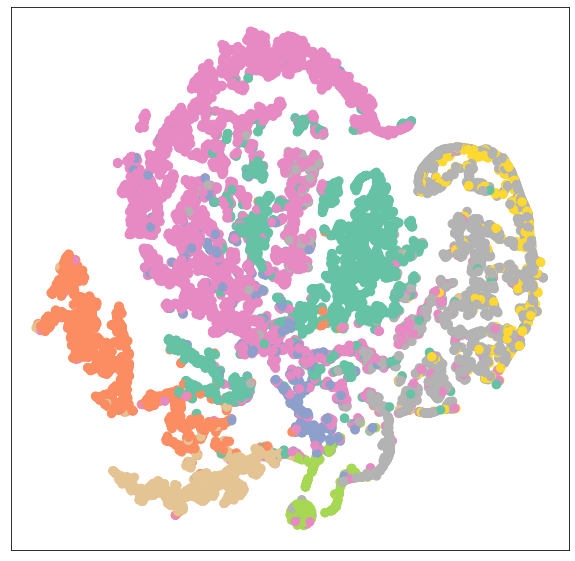

time: 2min 45s (started: 2023-03-15 07:22:28 +00:00)


In [ ]:
model.eval()

out = model(data.x, data.edge_index)
visualize(out, color=data.y)

/usr/local/lib/python3.8/dist-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


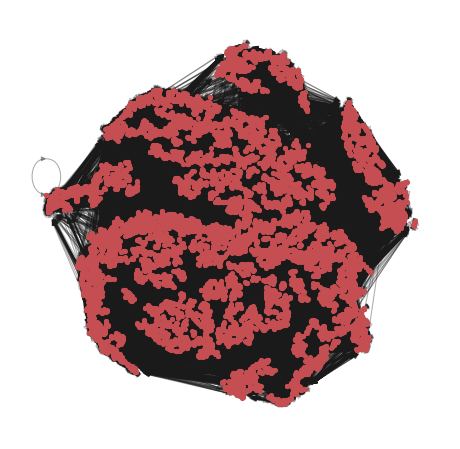

time: 40min 37s (started: 2023-02-23 04:56:59 +00:00)


In [ ]:
import networkx as nx
from torch_geometric.utils import to_networkx

# Obtenha as embeddings dos nós do grafo
with torch.no_grad():
    embeddings = model(dataset[0].x, dataset[0].edge_index)
    embeddings = embeddings.numpy()

# Reduza a dimensionalidade das embeddings usando o t-SNE
tsne = TSNE(n_components=2)
embeddings = tsne.fit_transform(embeddings)

# Obtenha o grafo em formato NetworkX
G = to_networkx(dataset[0])

# Plote os nós e arestas usando o Matplotlib
plt.figure(figsize=(8,8))
pos = {i: embeddings[i] for i in range(len(G.nodes))}
nx.draw_networkx_nodes(G, pos=pos, node_size=10, node_color='r')
nx.draw_networkx_edges(G, pos=pos, alpha=0.2)
plt.axis('off')
plt.show()

In [ ]:
cpu_percent, memory_mb, cpu_gc, cpu_percent_per_core = print_memory_and_cpu()
print ('After execution: \n')
print(cpu_percent, memory_mb, cpu_gc, cpu_percent_per_core)

Linux 5.10.147+ (14bf035bf07a) 	03/16/2023 	_x86_64_	(2 CPU)

04:00:35 PM   runq-sz  plist-sz   ldavg-1   ldavg-5  ldavg-15   blocked
04:00:36 PM         0       256      0.45      0.55      0.47         0
Average:            0       256      0.45      0.55      0.47         0

After execution: 

19.9 0.5507049560546875 0.11213317140936852 [21.1, 18.9]
time: 1.15 s (started: 2023-03-16 16:00:35 +00:00)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks

epochs = [row[0] for row in results]
cpu_values = [row[3] for row in results]
mem_values = [row[4] for row in results]


time: 444 ms (started: 2023-03-16 16:00:41 +00:00)


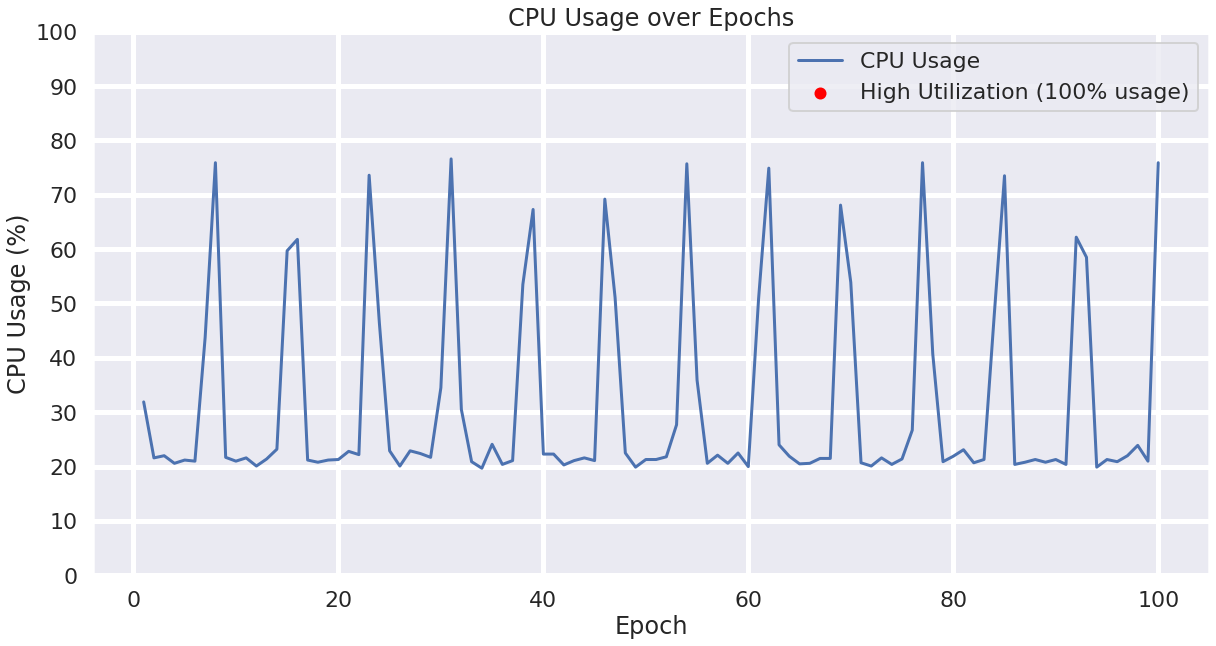

Percentage of High Utilization:  0.0
time: 390 ms (started: 2023-03-16 16:00:44 +00:00)


In [ ]:
# PLOT CPU USAGE

peak_indices, _ = find_peaks(cpu_values, height=100, plateau_size=1)

indices = [i for i in range(len(cpu_values)) if cpu_values[i] == 100.0]

plt.figure(figsize=(20,10))
sns.set(style="darkgrid")
sns.set_context("poster", font_scale = 1, rc={"grid.linewidth": 5})
plt.plot(epochs, cpu_values, label='CPU Usage')
plt.scatter([epochs[i] for i in indices], [100]*len(indices), color='red', s=100, label='High Utilization (100% usage)')
# plt.scatter([epochs[i] for i in peak_indices], [100]*len(peak_indices), color='blue', s=100, label='Peak of Saturation')
plt.title('CPU Usage over Epochs')
plt.xlabel('Epoch')
plt.ylabel('CPU Usage (%)')
plt.yticks(range(0, 101, 10))
plt.gca().set_yticklabels([_ * 10 for _ in range(11)])
plt.legend()
plt.show()

saturation = (len(indices) / len(epochs)) * 100
print('Percentage of High Utilization: ', saturation)

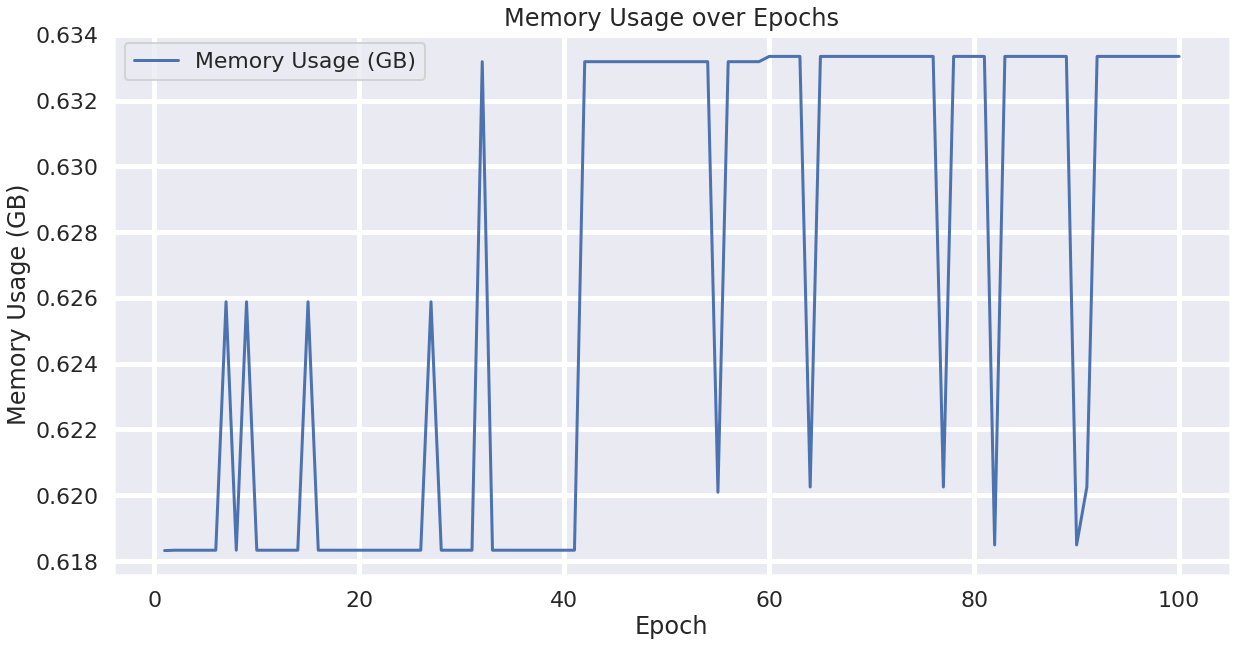

time: 340 ms (started: 2023-03-16 13:32:51 +00:00)


In [ ]:
# PLOT MEMORY USAGE
plt.figure(figsize=(20,10))
sns.set(style="darkgrid")
sns.set_context("poster", font_scale = 1, rc={"grid.linewidth": 5})
plt.plot(epochs, mem_values, label='Memory Usage (GB)')
plt.title('Memory Usage over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Memory Usage (GB)')
# plt.yticks(range(0, 101, 10))
# plt.gca().set_yticklabels([_ * 10 for _ in range(11)])
plt.legend()
plt.show()

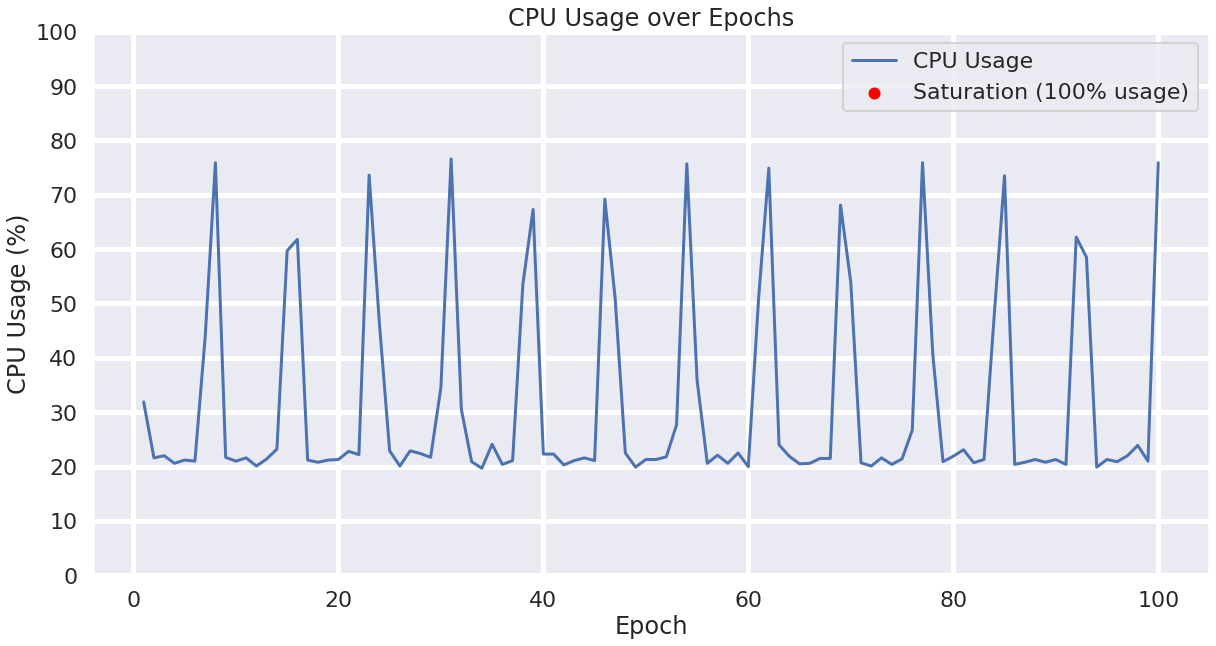

Percentage of High Utilization:  0.0
time: 305 ms (started: 2023-03-16 16:01:09 +00:00)


In [ ]:
# PLOT CPU USAGE

peak_indices, _ = find_peaks(cpu_values, height=100, plateau_size=1)

indices = [i for i in range(len(cpu_values)) if cpu_values[i] == 100.0]

plt.figure(figsize=(20,10))
sns.set(style="darkgrid")
sns.set_context("poster", font_scale = 1, rc={"grid.linewidth": 5})
plt.plot(epochs, cpu_values, label='CPU Usage')
plt.scatter([epochs[i] for i in indices], [100]*len(indices), color='red', s=100, label='Saturation (100% usage)')
# plt.scatter([epochs[i] for i in peak_indices], [100]*len(peak_indices), color='blue', s=100, label='Peak of Saturation')
plt.title('CPU Usage over Epochs')
plt.xlabel('Epoch')
plt.ylabel('CPU Usage (%)')
plt.yticks(range(0, 101, 10))
plt.gca().set_yticklabels([_ * 10 for _ in range(11)])
plt.legend()
plt.show()

saturation = (len(indices) / len(epochs)) * 100
print('Percentage of High Utilization: ', saturation)

In [ ]:
psutil.cpu_stats()

scpustats(ctx_switches=11995088, interrupts=9245220, soft_interrupts=5854349, syscalls=0)

time: 12.8 ms (started: 2023-03-15 09:07:29 +00:00)
